In [1]:
try:
    %load_ext autotime
except:
    !pip3 install ipython-autotime
    %load_ext autotime


try:
    %load_ext pulp
except:
    !pip3 install pulp
    

The pulp module is not an IPython extension.
time: 391 ms (started: 2024-10-24 18:08:50 -07:00)


<h1>Formulating and Solving ILPs using PULP.</h1>

We have already encountered PuLP as a package for solving linear programs. As it turns out, PuLP is quite useful in solving integer linear programming problems as well. We will show a few examples as an introduction to formulating and solving integer linear programming problems using PuLP. The overall approach is very similar to how linear programming problems are setup. <u>We simply need to make sure that the variables are declared as integer or binary variables</u>.

Let us start with a simple example.

<h2>Example 1 : Variant of Knapsack Problem</h2>
You are at a candy store and would like to buy  100 grams of candies. We have the problem of choosing candies to buy (think of this as the ILP version of the diet problem). We have a bunch of  𝑛 different varieties of candies  𝐷1,…,𝐷𝑛 that we could choose from.

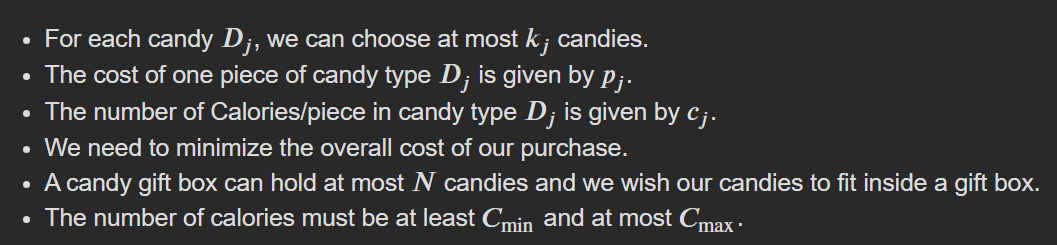

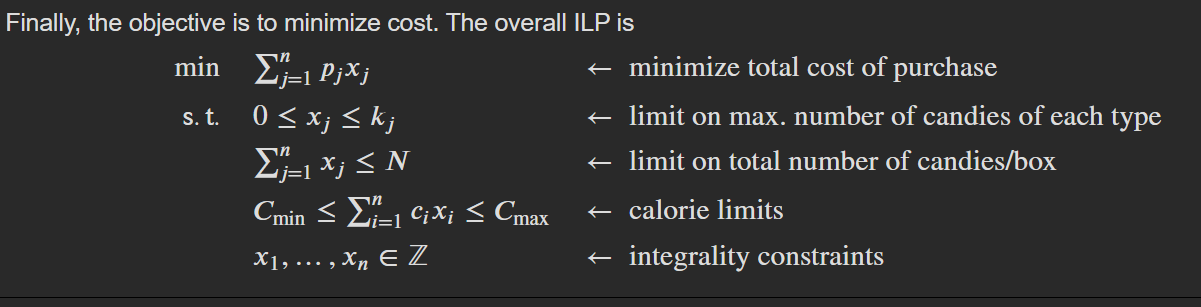

Let's implement this model in python using pulp

In [2]:
from pulp import * # get all the definitions from pulp library 

def solve_candy_knapsack(n, candy_number_limits, candy_prices, candy_calories, N, Cmin, Cmax):
    assert len(candy_number_limits) == n, 'size mismatch for candy limits'
    assert len(candy_prices) == n, 'size mismatch for candy prices'
    assert len(candy_calories) == n, 'size mismatch for candy calories'
    assert N >= 1, 'total number of candies per box must be 1 or more'
    assert Cmin <= Cmax, 'minimum calories is greater than the maximum calories'
    assert Cmin >=0, 'minimum calories should be greater than or equal to 0'
    prob = LpProblem('Candy Knapsack', LpMinimize)
    # add decision variables - n variables x1,x2,..,xn each of which represents quantity of corresponding candy chosen
    dVars = [LpVariable(f'x{i}',lowBound=0, upBound=ki, cat='Integer') for (i, ki) in enumerate(candy_number_limits)]
    # Now set the objective
    prob += lpSum([pj*xj for (pj,xj) in zip(candy_prices, dVars)])
    # Now add the constraints
    prob += lpSum(dVars) <= N # constraints on number of candies per box
    calories_of_candies = lpSum([pj*xj for (pj,xj) in zip(candy_calories, dVars)])
    prob += calories_of_candies <= Cmax
    prob += calories_of_candies >= Cmin
    status = prob.solve()
    if status == constants.LpStatusInfeasible:
        print('Problem is infeasible')
        return
    elif status == constants.LpStatusUnbounded:
        print('Problem is unbounded. Cannot proceed')
        return
    else:
        assert status == constants.LpStatusOptimal, 'Something went wrong while solving since status is either undefined or unsolved'
        # extract values
        print('Success: optimal answer found')
        solution_values = [x.varValue for x in dVars]
        for (j, svj) in enumerate(solution_values):
            print(f'\t Candy Type # {j}: {svj} candies')
        print(f'Total Cost: {sum([(pj*svj) for (pj, svj) in zip(candy_prices, solution_values)])}')
        print(f'Calories: {sum([cj*xj for (cj,xj) in zip(candy_calories, solution_values)])}')

    





time: 0 ns (started: 2024-10-24 20:04:38 -07:00)


In [3]:
n = 5
candy_number_limits = [10, 12, 10, 11, 10]
candy_prices = [0.2, 0.5, 0.1, 0.4, 0.8]
candy_calories = [25, 12, 22, 14, 33]
solve_candy_knapsack(5, candy_number_limits, candy_prices, candy_calories, 12, 250, 500)


C:\Users\hramm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pulp\pulp.py:1298: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Success: optimal answer found
	 Candy Type # 0: 2.0 candies
	 Candy Type # 1: 0.0 candies
	 Candy Type # 2: 10.0 candies
	 Candy Type # 3: 0.0 candies
	 Candy Type # 4: 0.0 candies
Total Cost: 1.4
Calories: 270.0
time: 281 ms (started: 2024-10-24 20:04:48 -07:00)


<h2> Set Cover Problem </h2>
We will now present another example involving binary variables.

Let's assume that you are planning a company party and there are  𝑛   people conveniently numbered  1,…,𝑛   that you could invite. We wish to invite at least  𝑚  people to attend. Therefore, HR tells you to respect the following constraints:

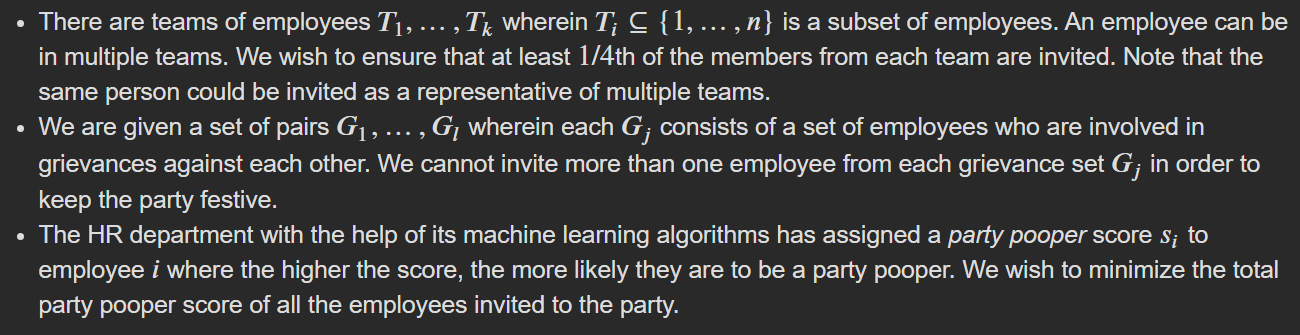

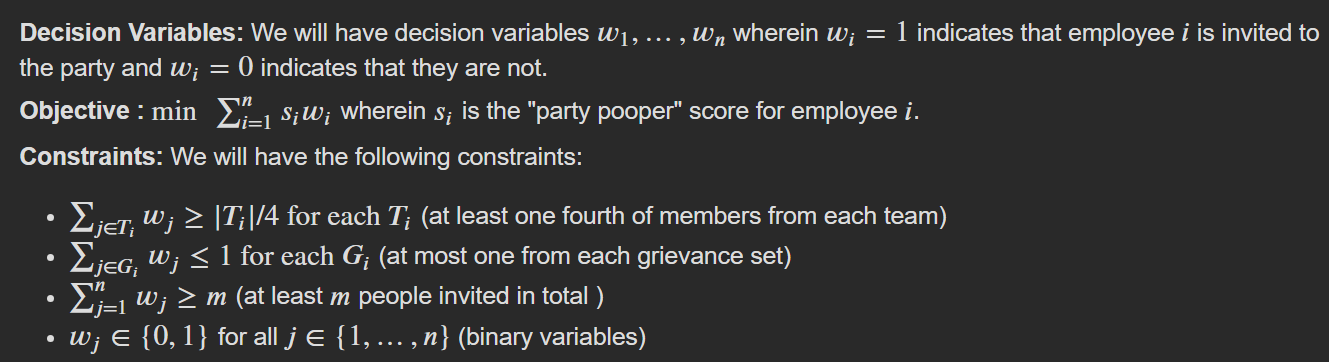








In [4]:
def plan_invite_list(n, m, T_lists, G_lists, pp_scores):
    assert m >= 0, 'Cannot invite a negative number of people'
    assert all( 0 <= j < n for ti in T_lists for j in ti ) # check that all employee IDs are valid
    assert all( 0<= j < n for gi in G_lists for j in gi)
    assert len(pp_scores) == n, 'Length of party pooper scores list does not match number of employees'
    prob = LpProblem('PartyPlanner', LpMinimize)
    # create decision variables
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(n)] # declare variables as binary
    # if we declared variables as binary they are automatically treated as either 0 or 1 in the optimization 
    # create objective
    prob += lpSum([si * wi for (si, wi) in zip(pp_scores, dvars)])
    # limit on number of invitees
    prob += sum(dvars) >= m
    # at least 1/4 th people from each team
    for ti in T_lists:
        prob += lpSum([dvars[j] for j in ti]) >= len(ti)/4
    # no more than one person per grievance set
    for gj in G_lists:
        prob += lpSum(dvars[j] for j in gj) <= 1
    # solve and get the result
    status = prob.solve()
    if status == constants.LpStatusInfeasible:
        print('infeasible LP')
        return 
    elif status != constants.LpStatusOptimal:
        print('Unbounded or undefined LP Status -- there is some mistake in the problem formulation since it cannot happen in theory')
        return 
    else: 
        assert status == constants.LpStatusOptimal
        # extract values
        sol = [x.varValue for x in dvars]
        for (j,wj) in enumerate(sol):
            if wj >= 1:
                print(f'Invite person {j}')
        print(f'Total # of invitees: {sum(sol)}')
        for j,tj in enumerate(T_lists):
            print(f'# of invitees from Team # {j}: {sum([sol[k] for k in tj])}')
        for k, gk in enumerate(G_lists):
            print(f'# of invitees from Grievance set # {k}: {sum([sol[j] for j in gk])}')
        return
        

time: 16 ms (started: 2024-10-24 20:32:51 -07:00)


In [5]:
n = 20
m = 12
T_lists = [[1, 5, 12, 18, 19], [2, 3, 4, 6, 7], [1, 2, 4, 7, 8, 9, 10, 11, 12, 14, 16], [1, 3, 4, 5, 6, 13, 15, 17, 18, 19], [1, 5, 7, 8,9, 19]]
G_lists = [[1, 5], [5, 19], [4, 7], [4, 12], [4, 19], [4, 18], [3, 4, 15, 19], [4, 7, 18, 2]]
pp_scores = [1, 2, 2, 1, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3.5, 1, 0.6, 0, 1, 8, 8]
plan_invite_list(n, m, T_lists, G_lists, pp_scores)

Invite person 0
Invite person 1
Invite person 2
Invite person 6
Invite person 8
Invite person 11
Invite person 12
Invite person 13
Invite person 14
Invite person 15
Invite person 16
Invite person 17
Total # of invitees: 12.0
# of invitees from Team # 0: 2.0
# of invitees from Team # 1: 2.0
# of invitees from Team # 2: 7.0
# of invitees from Team # 3: 5.0
# of invitees from Team # 4: 2.0
# of invitees from Grievance set # 0: 1.0
# of invitees from Grievance set # 1: 0.0
# of invitees from Grievance set # 2: 0.0
# of invitees from Grievance set # 3: 1.0
# of invitees from Grievance set # 4: 0.0
# of invitees from Grievance set # 5: 0.0
# of invitees from Grievance set # 6: 1.0
# of invitees from Grievance set # 7: 1.0
time: 62 ms (started: 2024-10-24 20:33:13 -07:00)


In [6]:
from random import randint
n = 32
m = 18
num_teams = 30
num_grievances = 6
T_lists = [list(set([randint(0,31) for k in range(randint(3,10))])) for i in range(num_teams)] # 30 random teams
G_lists = [list(set([randint(0,31) for k in range(randint(2,4))])) for i in range(num_grievances)] # 6 random pairs of grievances
for i, ti in enumerate(T_lists):
    print(f'\t Team # {i}: {ti}')
for j, gj in enumerate(G_lists):
    print(f'\t Grievance set # {j}: {gj}')
pp_scores = [randint(0, 8) for i in range(n)]
plan_invite_list(n, m, T_lists, G_lists, pp_scores)

	 Team # 0: [4, 6, 12, 19, 23, 24, 25]
	 Team # 1: [12, 13, 16, 21, 26, 28, 29, 30, 31]
	 Team # 2: [7, 8, 11, 16, 19, 26, 27, 28]
	 Team # 3: [24, 3, 13]
	 Team # 4: [1, 2, 6, 12, 16, 18, 25, 27]
	 Team # 5: [7, 12, 24, 25, 27, 28]
	 Team # 6: [7, 15, 16, 18, 21, 23, 25, 28]
	 Team # 7: [4, 14, 17, 24, 27]
	 Team # 8: [3, 4, 31]
	 Team # 9: [0, 11, 21]
	 Team # 10: [5, 28, 21]
	 Team # 11: [26, 27, 21, 7]
	 Team # 12: [25, 12, 7, 23]
	 Team # 13: [1, 2, 16, 20, 22, 26, 27, 28]
	 Team # 14: [9, 10, 16, 23, 24, 26]
	 Team # 15: [1, 2, 5, 6, 10, 15, 19, 29, 31]
	 Team # 16: [0, 2, 3, 4, 5, 20, 27, 30, 31]
	 Team # 17: [4, 10, 16, 17, 31]
	 Team # 18: [1, 11, 22, 28, 29, 30, 31]
	 Team # 19: [5, 7, 9, 11, 12, 14, 15, 20, 26, 27]
	 Team # 20: [25, 5, 13, 21]
	 Team # 21: [8, 1, 12, 6]
	 Team # 22: [2, 4, 8, 22, 30]
	 Team # 23: [0, 6, 10, 24, 29]
	 Team # 24: [4, 10, 11, 12, 18, 19, 26, 29]
	 Team # 25: [24, 17, 2, 31]
	 Team # 26: [0, 9, 17, 22, 27]
	 Team # 27: [3, 13, 15, 21, 24, 28]
	 